In [7]:
#Nehir Yüksekkaya 21307751  Li Fernando 21303270

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import *

ModuleNotFoundError: No module named 'pulp'

In [11]:
def f(x):
    return 1/(1+25*x**2)

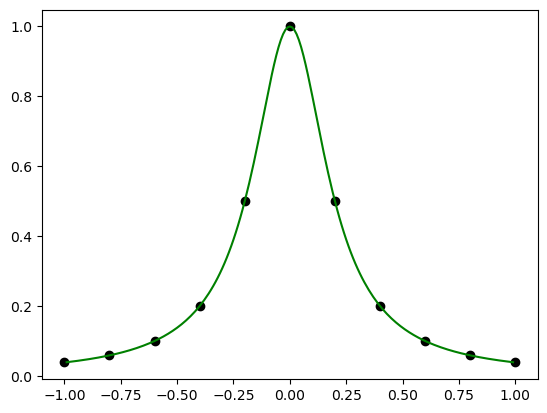

In [12]:
x=np.arange(-0.99,1,0.01)
y= f(x)
plt.plot(x,y, color='green')
x0=np.array([-1+i/5 for i in range (0,11)])
y0=f(x0)
plt.scatter(x0,y0,color='black')

In [13]:
def lagrange_interpolation(x_points, y_points, x):
    n = len(x_points)
    L = np.zeros_like(x, dtype=float)
    
    for i in range(n):
        l_i = np.ones_like(x, dtype=float)
        for j in range(n):
            if i != j:
                l_i *= (x - x_points[j]) / (x_points[i] - x_points[j])
        L += y_points[i] * l_i
    return L

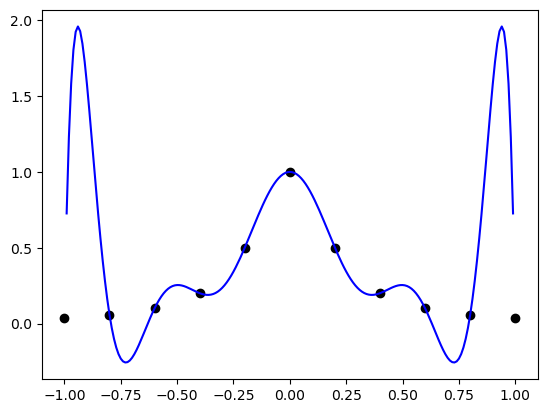

In [14]:
y2=lagrange_interpolation(x0, y0, x)
plt.plot(x,y2, color='blue')
plt.scatter(x0,y0,color='black')

In [15]:
x1=np.array([-1+i/5 for i in range (0,11)])
y1=f(x1)
model = LpProblem(name="Ex1", sense=LpMinimize) 
n=len(x1)

i=[0,1,2,3,4,5,6,7,8,9,10]
a=LpVariable.matrix("a", list(range(n-1)))
b=LpVariable.matrix("b", list(range(n-1)))
c=LpVariable.matrix("c", list(range(n-1)))
d=LpVariable.matrix("d", list(range(n-1)))

NameError: name 'LpProblem' is not defined

In [ ]:
model +=0

In [ ]:
x1=np.array([-1+i/5 for i in range (0,11)])
y1=f(x1)

In [ ]:
for j in range(n-1):
    model += (a[j] == y1[j])
    model +=a[j]+b[j]*(x1[j+1]-x1[j])+c[j]*((x1[j+1]-x1[j])**2)+d[j]*((x1[j+1]-x1[j])**3)==y1[j+1]
    
for j in range(n-2):  
    model += b[j]+2*c[j]*(x1[j+1]-x1[j])+3*d[j]*((x1[j+1]-x1[j])**2)==b[j+1]+2*c[j+1]*(x1[j+1]-x1[j+1])+3*d[j+1]*((x1[j+1]-x1[j+1])**2)
    model +=2*c[j]+6*d[j]*(x1[j+1]-x1[j])==2*c[j+1]+6*d[j+1]*(x1[j+1]-x1[j+1])

model+=2*c[0]+6*d[0]*(x1[0]-x1[0])==0
model+=2*c[n-2]+6*d[n-2]*(x1[n-1]-x1[n-2])==0

In [ ]:
status = model.solve(solver=GLPK(msg=True,keepFiles=True)) #keepFiles permet de créer un fichier .sol contenant la solution

# Affiche le statut de la solution (optimale, non borné, etc.)
print("Status:", LpStatus[model.status])

# Affiche la valeur de la fonction objectif
print("objective=", value(model.objective))

for i in range (n-1):
    print(value(a[i])),print(value(b[i])),print(value(c[i])),print(value(d[i]))

In [ ]:
s=np.array([ None for i in range (0,11)])
for i in range(n-1):
    s[x[i]]=value(a[i])+value(b[i])*(x[i]-x1[i])+value(c[i])*((x[i]-x1[i])**2)+value(d[i])*((x[i]-x1[i])**3)
plt.plot(x1,s)

In [ ]:
#EX2

In [16]:
def B(x, k, i, u):
   if k == 0:
      return 1.0 if u[i] <= x < u[i+1] else 0.0
   if u[i+k] == u[i]:
      c1 = 0.0
   else:
      c1 = (x - u[i])/(u[i+k] - u[i]) * B(x, k-1, i, u)
   if u[i+k+1] == u[i+1]:
      c2 = 0.0
   else:
      c2 = (u[i+k+1] - x)/(u[i+k+1] - u[i+1]) * B(x, k-1, i+1, u)
   return c1 + c2
def ispline(x, k, i, u):
    l=0
    while u[l]<=x :
        l=l+1
    j=l-1  
    if j<i+1: return 0.
    if j-k>i: return 1.
    v = 0.
    for m in range(i+1,j+1):
        v += B(x, k, m, u)
    return v

In [17]:
def bcurve(x, u, c, k):
    res=0
    for i in range(0,8):
        res+=B(x, k, i, u)*c[i]
    return res

In [18]:
def icurve(x, u, c, k):
    res=0
    for i in range(0,7):
        res+=ispline(x, k, i, u)*c[i]
    return res

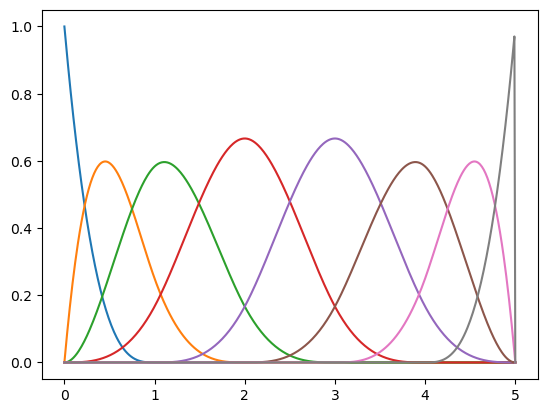

In [19]:
x5=np.arange(0,5.01,0.01)
u=[0, 0, 0, 0, 1, 2, 3, 4, 5, 5, 5, 5]
for i in range(0,8):
    y5=[B(j,3,i,u) for j in x5]
    plt.plot(x5,y5)  

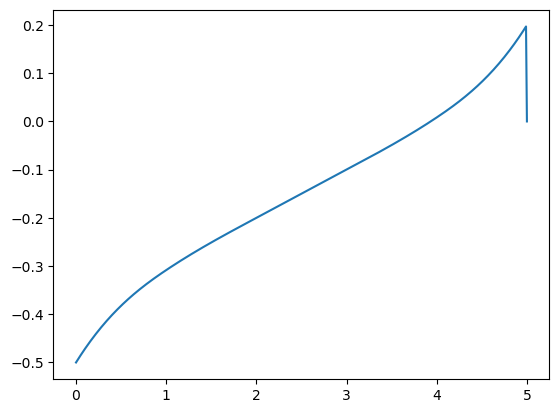

In [20]:
c1=np.arange(-0.5,1,0.1)
y6=[bcurve(j, u, c1, 3) for j in x5 ]
plt.plot(x5,y6)  

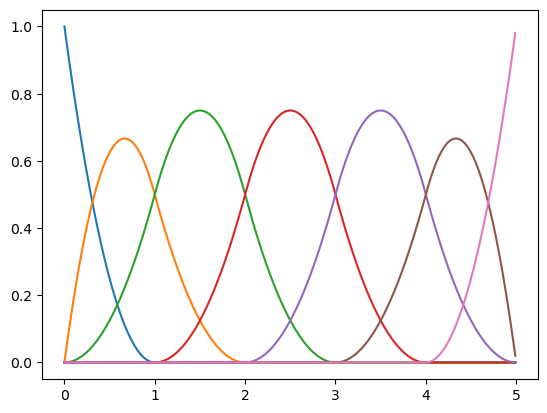

In [21]:
x6=np.arange(0,5,0.01)
v=[0, 0, 0, 1, 2, 3, 4, 5, 5, 5]
for i in range(0,7):
    y7=[B(j,2,i,v) for j in x6]
    plt.plot(x6,y7)  

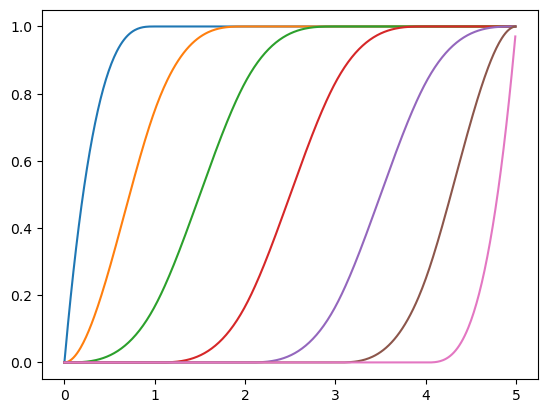

In [22]:
for i in range(0,7):
    y8=[ispline(j,3,i,u) for j in x6]
    plt.plot(x6,y8)  

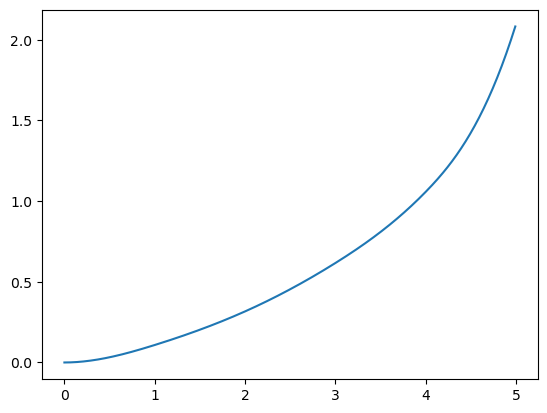

In [23]:
c2=np.arange(0,1,0.1)
y9=[icurve(j, u, c2, 3) for j in x6 ]
plt.plot(x6,y9)  

In [24]:
#EX3

In [36]:
x=np.array([1,2,3,4,5,6,7,8,9])
y=np.array([8,12,9,6,15,10,12,7,10])
q=8
k=3
m=q+k+1
v=np.array([0,0,0,0,1/6,2/6,3/6,4/6,5/6,1,1,1,1])
p=[(0,0)]*q
for i in range(q):
    p[i]=(x[i],y[i])

In [42]:
def f_x(x):
    res=0
    for i in range(q):
        res += p[i][0]*B(x,k,i,v)
    return res

In [43]:
def f_y(x):
    res=0
    for i in range(q):
        res += p[i][1]*B(x,k,i,v)
    return res

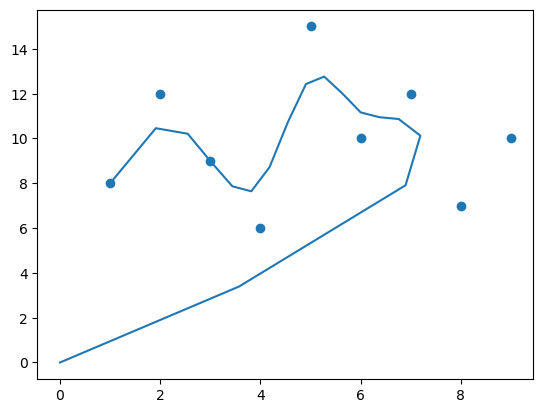

In [49]:
vals=np.linspace(u[0],u[q+1],100)
curve_x=[f_x(x) for x in vals]
curve_y=[f_y(x) for x in vals]
plt.scatter(x,y)
plt.plot(curve_x,curve_y)

In [50]:
#Ex4

In [51]:
X=np.array([18,5,4,6,19,10,19,12,20,9,9,2,14,7,15,4,8,16,4,1])
Y=np.array([14,9,8,8,17,15,19,14,18,15,14,10,7,10,11,8,13,8,8,10])

In [53]:
model =LpProblem(name="Ex4",sense=LpMinimize)
n=20
v=np.array([0,0,0,0,5,10,15,20,20,20,20])
m=len(v)
k=3
X=np.array([18,5,4,6,19,10,19,12,20,9,9,2,14,7,15,4,8,16,4,1])
Y=np.array([14,9,8,8,17,15,19,14,18,15,14,10,7,10,11,8,13,8,8,10])
z=LpVariable.matrix("z",list(range(1,n+1)),lowBound=0)
alpha=LpVariable.matrix("a",list(range(m+k+1)),lowBound=0)
def f(x,v,alpha,k):
    res=0
    for i in range(m-k-1):
        res+=alpha[i]*B(x,k,i,v)
    return res
model+=lpSum(z)
for i in  range(n):
    model+=z[i]>=Y[i]-f(X[i],v,alpha,k)
    model+=z[i]>=-Y[i]+f(X[i],v,alpha,k)
status=model.solve(solver=GLPK(msg=True,keepFiles=True))

print("Status:", LpStatus[model.status])

# Affiche la valeur de la fonction objectif
print("objective=", value(model.objective))

NameError: name 'LpProblem' is not defined

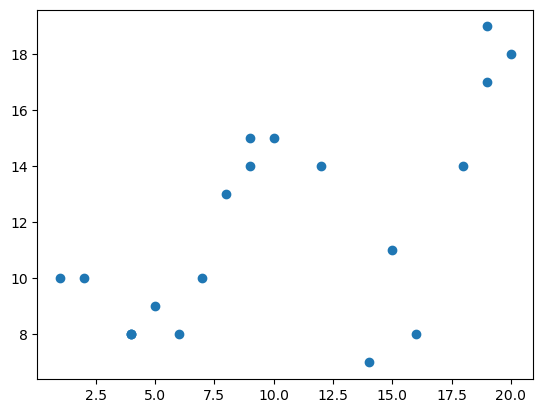

In [54]:
plt.scatter(X,Y)

In [56]:
alphav=[value(alpha[i]) for i in range(len(alpha))]
x_vals=np.linspace(min(X),max(X),100)
y_vals=[f(x,v,alphav,k)for x in x_vals]
plt.plot(x_vals,y_vals)
plt.scatter(X,Y)

NameError: name 'alpha' is not defined

In [57]:
model =LpProblem(name="Ex4",sense=LpMinimize)
n=20
v=np.array([0,0,0,0,2.5,5,7.5,10,12.5,15,17.5,20,20,20,20])
m=len(v)
k=3
X=np.array([18,5,4,6,19,10,19,12,20,9,9,2,14,7,15,4,8,16,4,1])
Y=np.array([14,9,8,8,17,15,19,14,18,15,14,10,7,10,11,8,13,8,8,10])
z=LpVariable.matrix("z",list(range(1,n+1)),lowBound=0)
alpha=LpVariable.matrix("a",list(range(m+k+1)),lowBound=0)
def f(x,v,alpha,k):
    res=0
    for i in range(m-k-1):
        res+=alpha[i]*B(x,k,i,v)
    return res
model+=lpSum(z)
for i in  range(n):
    model+=z[i]>=Y[i]-f(X[i],v,alpha,k)
    model+=z[i]>=-Y[i]+f(X[i],v,alpha,k)
status=model.solve(solver=GLPK(msg=True,keepFiles=True))

print("Status:", LpStatus[model.status])

# Affiche la valeur de la fonction objectif
print("objective=", value(model.objective))

NameError: name 'LpProblem' is not defined

In [58]:
alphav=[value(alpha[i]) for i in range(len(alpha))]
x_vals=np.linspace(min(X),max(X),100)
y_vals=[f(x,v,alphav,k)for x in x_vals]
plt.plot(x_vals,y_vals)
plt.scatter(X,Y)

NameError: name 'alpha' is not defined

In [59]:
#EX5

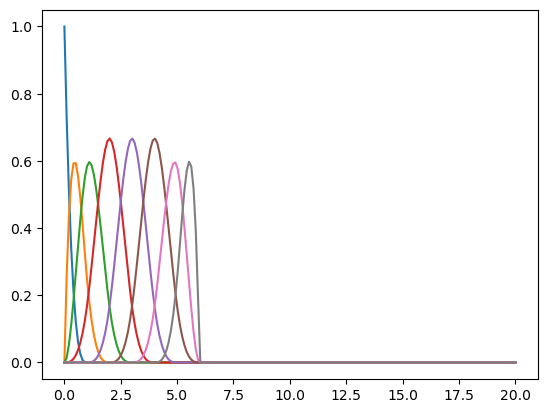

In [106]:
x=np.array([1,6,8,12,10,14,15,17,20,23,3,4,7,12,13,16,18,19,20,21])
y=np.array([14,15,14,11,14,6,7,8,6,2,12,14,13,5,7,8,7,6,5,3])
v=np.array([0,0,0,0,4,8,12,16,20,20,20,20])
k=3
for i in range(m-k-1):
    x_x=np.linspace(0,20,200)
    y_y=[B(a,k,i,u)for a in x_x]
    plt.plot(x_x,y_y)

In [80]:
model =LpProblem(name="Ex4",sense=LpMinimize)
n=20
m=len(v)
z=LpVariable.matrix("z",list(range(1,n+1)),lowBound=0)
alpha=LpVariable.matrix("a",list(range(m+k+1)),lowBound=0)
def f(x,v,alpha,k):
    res=0
    for i in range(m-k-1):
        res+=alpha[i]*B(x,k,i,v)
    return res
model+=lpSum(z)
for i in  range(n):
    model+=z[i]>=Y[i]-f(X[i],v,alpha,k)
    model+=z[i]>=-Y[i]+f(X[i],v,alpha,k)
status=model.solve(solver=GLPK(msg=True,keepFiles=True))

print("Status:", LpStatus[model.status])

# Affiche la valeur de la fonction objectif
print("objective=", value(model.objective))

NameError: name 'LpProblem' is not defined

In [81]:
alphav=[value(alpha[i]) for i in range(len(alpha))]
x_vals=np.linspace(min(X),max(X),100)
y_vals=[f(x,v,alphav,k)for x in x_vals]
plt.plot(x_vals,y_vals)
plt.scatter(X,Y)

NameError: name 'alpha' is not defined

In [105]:
model =LpProblem(name="Ex4",sense=LpMinimize)
n=20
m=len(v)
k=3
x=np.array([1,6,8,12,10,14,15,17,20,23,3,4,7,12,13,16,18,19,20,21])
y=np.array([14,15,14,11,14,6,7,8,6,2,12,14,13,5,7,8,7,6,5,3])
v=np.array([0,0,0,0,4,8,12,16,20,20,20,20])
z=LpVariable.matrix("z",list(range(1,n+1)),lowBound=0)
alpha=LpVariable.matrix("a",list(range(m+k+1)),lowBound=0)
def f(x,v,alpha,k):
    res=0
    for i in range(m-k-1):
        res+=alpha[i]*B(x,k,i,v)
    return res
model+=lpSum(z)
for i in  range(n):
    model+=z[i]>=Y[i]-f(X[i],v,alpha,k)
    model+=z[i]>=-Y[i]+f(X[i],v,alpha,k)
for i in range(m-k-2):
    model+=alpha[i]>=alpha[i+1]
status=model.solve(solver=GLPK(msg=True,keepFiles=True))

print("Status:", LpStatus[model.status])

# Affiche la valeur de la fonction objectif
print("objective=", value(model.objective))

NameError: name 'LpProblem' is not defined

In [ ]:
alphav=[value(alpha[i]) for i in range(len(alpha))]
x_vals=np.linspace(min(X),max(X),100)
y_vals=[f(x,v,alphav,k)for x in x_vals]
plt.plot(x_vals,y_vals)
plt.scatter(X,Y)